In [1]:
import numpy as np
from matplotlib import pyplot as plt
from scipy import stats
from astropy.visualization import hist
from scipy.stats import norm
import scipy

In [39]:
distG = norm(loc =1 , scale=0.2)

[]

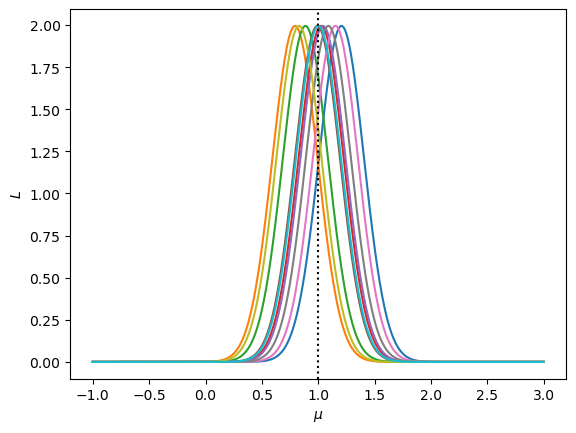

In [72]:
N = 10
data = distG.rvs(N)
for i in data:
    # Scan across 1000 possible mu values from 3 to 20.
    mu_proposed = np.linspace(-1,3,1000)
    
    # compute the lnL for each possible mu.
    L_scan = []
    for mu in mu_proposed:
        L_temp = norm.pdf(i, loc=mu, scale=0.2) # gives you the log prob. density; useful!
        L_temp = np.sum(L_temp) # sum over the log pmf of all data points
        L_scan.append(L_temp)
        
    # convert to numpy array
    L_scan = np.array(L_scan)
    if i == data[0] : L_tot = L_scan
    else : L_tot = L_tot*L_scan
        
    # mu_proposed that maximizes the lnL.
    plt.plot(mu_proposed,L_scan)
    
    #findmax = mu_proposed[np.argmax(L_scan)]
    
    
plt.axvline(1,c='black',ls='dotted')

plt.xlabel(r'$\mu$')
plt.ylabel(r'$L$')
plt.plot()

1.0020020020020022


[]

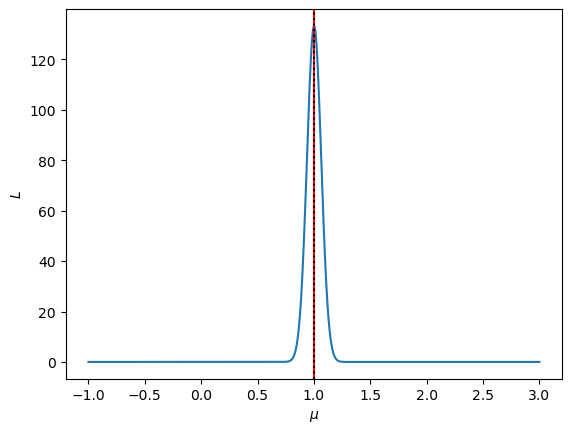

In [73]:

plt.plot(mu_proposed,L_tot)
    
findmax = mu_proposed[np.argmax(L_tot)]
print(findmax)
plt.axvline(findmax,c='red')
    
plt.axvline(1,c='black',ls='dotted')

plt.xlabel(r'$\mu$')
plt.ylabel(r'$L$')
plt.plot()

In [78]:
diff = np.diff(np.log(L_tot), n=2)
delta_mu = (1-findmax)/np.sqrt(N)